# <a id='toc1_'></a>[Imports](#toc0_)

In [2]:
import pickle
import pickletools
import datetime
from eolearn.core import EOPatch
from pyproj import Proj, transform

import numpy as np
import pandas as pd

import geopandas as gpd
import rasterio as rio
from rasterio import features

from patchify import patchify

import torch

import matplotlib.pyplot as plt

import albumentations as TA
from tqdm import tqdm

from torch.utils.data import Dataset


# <a id='toc2_'></a>[Device Configuration](#toc0_)

In [3]:
DEVICE  = torch.device(f"cuda:0" if torch.cuda.is_available() else "cpu")
DEVICE  = "cpu"
print(DEVICE)


cpu


# <a id='toc3_'></a>[Constants](#toc0_)

- Sentinel 2 Bands information
-------------------------------
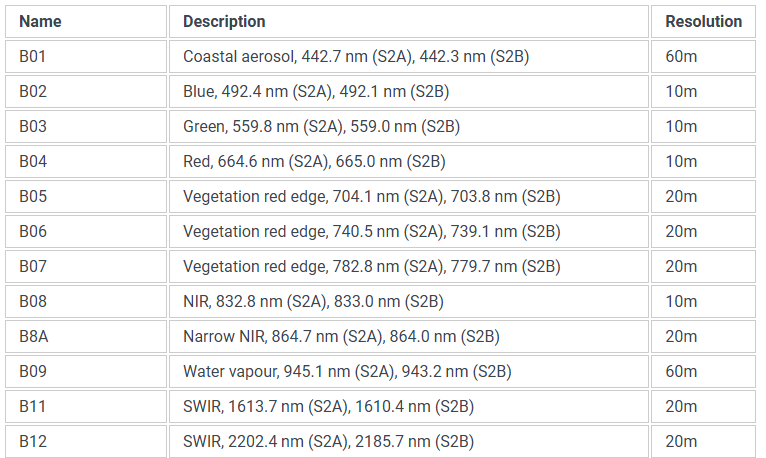

In [4]:
BANDS = ["B01","B02","B03","B04","B05","B06","B07","B08","B8A","B09","B11","B12"]
BAND_CLASSES = ["COSTAL_AEROSOL", "BLUE", "GREEN", "RED",
                "VEGETATION_RED_EDGE-704NM", "VEGETATION_RED_EDGE-740NM",
                "VEGETATION_RED_EDGE-782NM", "NIR","NARROW_NIR", "WATER_VAPOUR",
                "SWIR-1612NM","SWIR-2202NM"]

CROP_CLASSES = ["No data", "Wheat", "Rye", "Barley", "Oats", "Corn", "Oil Seeds", "Root Crops",
                "Meadows", "Forage Crops"]
CROP_IDS = [-1, 1, 2, 3, 4, 5, 6, 7, 8, 9]


In [5]:
base_path = "../Dataset"

dataset = base_path + "/s2-utm-33N-18E-242N-2018"
train_geojson_path = base_path + "/br-18E-242N-crop-labels-train-2018.geojson"

folder = "/DS3"
subfolder1 = "/Temporal Data"

data_path = dataset+folder
temporal_data_path = dataset+folder+subfolder1


# <a id='toc4_'></a>[Understanding Data](#toc0_)

## <a id='toc4_1_'></a>[Helper functions](#toc0_)

In [5]:
def formatCordinates(cordinate): 
    # Define the UTM projection (for example, UTM Zone 33N)
    utm_proj = Proj(proj="utm", zone=33, datum="WGS84")
    
    # Define the WGS84 (lat, lon) projection
    latlon_proj = Proj(proj="latlong", datum="WGS84")
    
    # Convert UTM to Latitude/Longitude
    longitude, latitude = transform(utm_proj, latlon_proj, cordinate[0], cordinate[1])
    
    print(f"Latitude = {latitude}, Longitude = {longitude}")


## <a id='toc4_2_'></a>[Train data - Germany: 2018-242N](#toc0_)

### <a id='toc4_2_1_'></a>[Meta info](#toc0_)

In [11]:
# Replace 'filename.pkl' with the path to your pickle file
path = dataset + '/meta_info.pkl'

with open(path, 'rb') as file:
    pickled_data = pickletools.dis(file)


    0: \x80 PROTO      3
    2: c    GLOBAL     'eolearn.core.eodata _FeatureDict'
   36: q    BINPUT     0
   38: )    EMPTY_TUPLE
   39: \x81 NEWOBJ
   40: q    BINPUT     1
   42: (    MARK
   43: X        BINUNICODE 'size_x'
   54: q        BINPUT     2
   56: M        BININT2    2400
   59: X        BINUNICODE 'size_y'
   70: q        BINPUT     3
   72: M        BININT2    2400
   75: X        BINUNICODE 'time_interval'
   93: q        BINPUT     4
   95: c        GLOBAL     'datetime datetime'
  114: q        BINPUT     5
  116: C        SHORT_BINBYTES b'\x07\xe2\x01\x01\x00\x00\x00\x00\x00\x00'
  128: q        BINPUT     6
  130: \x85     TUPLE1
  131: q        BINPUT     7
  133: R        REDUCE
  134: q        BINPUT     8
  136: h        BINGET     5
  138: C        SHORT_BINBYTES b'\x07\xe2\x0c\x1f\x17;;\x00\x00\x00'
  150: q        BINPUT     9
  152: \x85     TUPLE1
  153: q        BINPUT     10
  155: R        REDUCE
  156: q        BINPUT     11
  158: \x86     TUPLE2
 

In [12]:
with open(path, 'rb') as file:
    data = file.read()  # Read the first 100 bytes
    print(data)


b'\x80\x03ceolearn.core.eodata\n_FeatureDict\nq\x00)\x81q\x01(X\x06\x00\x00\x00size_xq\x02M`\tX\x06\x00\x00\x00size_yq\x03M`\tX\r\x00\x00\x00time_intervalq\x04cdatetime\ndatetime\nq\x05C\n\x07\xe2\x01\x01\x00\x00\x00\x00\x00\x00q\x06\x85q\x07Rq\x08h\x05C\n\x07\xe2\x0c\x1f\x17;;\x00\x00\x00q\t\x85q\nRq\x0b\x86q\x0cX\x05\x00\x00\x00maxccq\rK\x01X\x0f\x00\x00\x00time_differenceq\x0ecdatetime\ntimedelta\nq\x0fK\x00M \x1cK\x00\x87q\x10Rq\x11u}q\x12(X\x0c\x00\x00\x00feature_typeq\x13ceolearn.core.constants\nFeatureType\nq\x14X\t\x00\x00\x00meta_infoq\x15\x85q\x16Rq\x17X\x04\x00\x00\x00ndimq\x18NX\t\x00\x00\x00is_vectorq\x19\x89ub.'


### <a id='toc4_2_2_'></a>[Timestamps](#toc0_)

In [5]:
path = dataset + '/timestamp.pkl'

try:
    # Replace 'filename.pkl' with the path to your pickle file
    with open(path, 'rb') as file:
        data = pickle.load(file)

        readable_dates = [dt.strftime("%Y-%m-%d %H:%M:%S") for dt in data]
    
        # Now 'data' contains the contents of the pickle file
        #print(readable_dates)

        print(f"Start date: {min(readable_dates)}\nEnd Date: {max(readable_dates)}")
        print(f"No of timestamps: {len(readable_dates)}")
except Exception as e:
    print(f"An error occurred: {e}")


Start date: 2018-01-02 10:24:20
End Date: 2018-12-30 10:16:06
No of timestamps: 144


In [38]:
for x,i in enumerate(readable_dates):
    print(x,i)


0 2018-01-02 10:24:20
1 2018-01-04 10:14:03
2 2018-01-07 10:24:01
3 2018-01-09 10:15:36
4 2018-01-12 10:23:55
5 2018-01-14 10:13:47
6 2018-01-17 10:23:41
7 2018-01-19 10:13:31
8 2018-01-22 10:23:23
9 2018-01-24 10:13:52
10 2018-01-27 10:23:14
11 2018-01-29 10:12:47
12 2018-02-01 10:22:37
13 2018-02-03 10:12:37
14 2018-02-06 10:22:06
15 2018-02-08 10:11:53
16 2018-02-11 10:21:39
17 2018-02-13 10:11:18
18 2018-02-16 10:21:02
19 2018-02-18 10:13:13
20 2018-02-21 10:20:33
21 2018-02-23 10:15:08
22 2018-02-26 10:20:50
23 2018-02-28 10:10:21
24 2018-03-03 10:20:19
25 2018-03-05 10:13:15
26 2018-03-08 10:22:41
27 2018-03-10 10:10:20
28 2018-03-13 10:25:40
29 2018-03-15 10:10:38
30 2018-03-18 10:20:16
31 2018-03-20 10:10:21
32 2018-03-23 10:20:21
33 2018-03-25 10:15:11
34 2018-03-28 10:20:18
35 2018-03-30 10:14:39
36 2018-04-02 10:24:35
37 2018-04-04 10:10:21
38 2018-04-07 10:20:20
39 2018-04-09 10:13:43
40 2018-04-12 10:20:24
41 2018-04-14 10:15:36
42 2018-04-17 10:20:21
43 2018-04-19 10:14:5

### <a id='toc4_2_3_'></a>[Area Cordinates](#toc0_)

In [15]:
path = dataset + '/bbox.pkl'

try:
    # Replace 'filename.pkl' with the path to your pickle file
    with open(path, 'rb') as file:
        data = list(pickle.load(file))

        # Now 'data' contains the contents of the pickle file
        print("Start point: ")
        formatCordinates(data[:2])
        print("End point: ")
        formatCordinates(data[2:])
except Exception as e:
    print(f"An error occurred: {e}")


Start point: 
Latitude = 52.417989999999996, Longitude = 14.000120000000003
End point: 
Latitude = 52.63620000888608, Longitude = 14.349811619358587


C:\Users\2405647\AppData\Local\Temp\ipykernel_23696\1556969601.py:9: FutureWarning: This function is deprecated. See: https://pyproj4.github.io/pyproj/stable/gotchas.html#upgrading-to-pyproj-2-from-pyproj-1
  longitude, latitude = transform(utm_proj, latlon_proj, cordinate[0], cordinate[1])
C:\Users\2405647\AppData\Local\Temp\ipykernel_23696\1556969601.py:9: FutureWarning: This function is deprecated. See: https://pyproj4.github.io/pyproj/stable/gotchas.html#upgrading-to-pyproj-2-from-pyproj-1
  longitude, latitude = transform(utm_proj, latlon_proj, cordinate[0], cordinate[1])


### <a id='toc4_2_4_'></a>[Load Train Data](#toc0_)

In [25]:
path = dataset + '/BANDS.npy'

# Load the .npy file
data_2018_242N = np.load(path)


KeyboardInterrupt: 

In [ ]:
# Now 'data' holds the contents of the file
print(data_2018_242N.shape)



(144, 2400, 2400, 1)


In [ ]:
# Overwrite data with selected bands with below method for memory optimisation
# Uncomment when required
# data_2018_242N = np.concatenate((data_2018_242N[..., :3], np.expand_dims(data_2018_242N[..., 7], axis=-1)), axis=3)
# np.save(temporal_data_path+'/1.NIR_bands_data.npy', data_2018_242N)


### <a id='toc4_2_5_'></a>[Load mask](#toc0_)

In [22]:
path = dataset + '/SCL.npy'
cloud_mask_2018_242N = np.load(path)


In [23]:
print(cloud_mask_2018_242N.shape)

print(np.unique(cloud_mask_2018_242N[:][:][:]))


(144, 2400, 2400, 1)
[ 0  2  3  4  5  6  7  8  9 10 11]


### <a id='toc4_2_6_'></a>[Load the json and train labels](#toc0_)

In [ ]:
min_area = 500 # in meters/square
labels = gpd.read_file(train_geojson_path)

with open((dataset + '/bbox.pkl'), 'rb') as f:
            bbox = pickle.load(f)
            crs = str(bbox.crs)
            minx, miny, maxx, maxy = bbox.min_x, bbox.min_y, bbox.max_x, bbox.max_y

# project to same coordinate reference system (crs) as the imagery
labels = labels.to_crs(crs)

mask = labels.geometry.area > min_area
print(f"ignoring {(~mask).sum()}/{len(mask)} fields with area < {min_area}m2")
labels = labels.loc[mask]

#self.bands = np.load(os.path.join(rootpath, "data", "BANDS.npy"))
#self.clp = np.load(os.path.join(rootpath, "data", "CLP.npy"))
# bands = np.concatenate([bands, clp], axis=-1) # concat cloud probability
_, width, height, _ = data_2018_242N.shape

transform = rio.transform.from_bounds(minx, miny, maxx, maxy, width, height)

fid_mask = features.rasterize(zip(labels.geometry, labels.fid), 
                              all_touched=True,
                              transform=transform, 
                              out_shape=(height, width),
                              default_value=-1,
                              nodata=-1)

assert len(np.unique(fid_mask)) > 0, f"vectorized fid mask contains no fields. " \
                                     f"Does the label geojson {train_geojson_path} cover the region defined by {dataset}?"

crop_mask = features.rasterize(zip(labels.geometry, labels.crop_id),
                               all_touched=True,
                               transform=transform,
                               out_shape=(height, width),
                               default_value=-1,
                               nodata=-1)

assert len(np.unique(crop_mask)) > 0, f"vectorized fid mask contains no fields. " \
                                      f"Does the label geojson {train_geojson_path} cover the region defined by {dataset}?"

#Replace 0 with -1 to indicate clear difference between the no data areaa
#To be noted while defining loss function to make discourage class imbalance
crop_mask = np.where(crop_mask == 0, -1, crop_mask)


In [17]:
print(crop_mask.shape)
print(np.unique(crop_mask, return_counts=True))


(2400, 2400)
(array([-1,  1,  2,  3,  4,  5,  6,  7,  8,  9]), array([2797961,  623835,  453365,  279643,   48665,  544897,  507156,
         16917,  262077,  225484], dtype=int64))


# <a id='toc5_'></a>[Handling data](#toc0_)

## <a id='toc5_1_'></a>[Helper functions](#toc0_)

### <a id='toc5_1_1_'></a>[To display image(s)](#toc0_)

In [12]:
def display_images(data_patches):
    for i in range(data_patches.shape[0]):
        patch = data_patches[i,...]
        indices = [patch[...,0:3], patch[...,:],]
        titles = ['RGB', 'RGB-NIR']

        fig, axs = plt.subplots(1, 2, figsize=(16, 4))
        for ax, idx_map, title in zip(axs, indices, titles):
            im = ax.imshow(idx_map, cmap='RdYlGn', vmin=-1, vmax=1)
            ax.set_title(title)
            ax.axis('off')
            plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

        plt.tight_layout()
        plt.show()


### <a id='toc5_2_2_'></a>[Save labels](#toc0_)

In [ ]:
# Uncomment when required
# np.save((data_path+'/labels2.npy'),crop_mask) 


# Selecting RGB + NIR bands and dividing it into patches

bands_data_start_date_path = r'../Dataset/s2-utm-33N-18E-242N-2018/DS1/1_bands_2018-01-02.npy'
bands_data_31_july_path = r'../Dataset/s2-utm-33N-18E-242N-2018/DS1/2_bands_2018-07-31.npy'
train_labels_path = r'../Dataset/s2-utm-33N-18E-242N-2018/DS1/3_labels.npy'


### <a id='toc5_3_2_'></a>[Calculate the vegetation indexs](#toc0_)

In [12]:
def select_rgb_and_nir_bands(data, device=None):
    """
    Compute EVI, NDWI, GNDVI, and NDRE from Sentinel-2 data cube.

    Parameters:
    - data (np.ndarray or torch.Tensor): shape (..., 12), Sentinel-2 bands in fixed order:
      ["B01","B02","B03","B04","B05","B06","B07","B08","B8A","B09","B11","B12"]
    - device (torch.device, optional): Device to run the computation on (default is None, which uses the CPU)

    Returns:
    - torch.Tensor: shape (t, x, y, 4), stacked EVI, NDWI, GNDVI, NDRE
    """

    # If input is a numpy array, convert it to a torch tensor and move it to the device
    if isinstance(data, np.ndarray):
        data = torch.tensor(data, dtype=torch.float32, device=device if device else 'cpu')

    assert data.shape[-1] == 12, \
        f"Expected input shape (..., 12), got {data.shape}"

    # Extract relevant bands
    BLUE = data[..., 1]   # B02
    GREEN = data[..., 2]  # B03
    RED = data[..., 3]    # B04
    # RE_705 = data[..., 4] # B05
    # RE_740 = data[..., 5] # B06
    # RE_783 = data[..., 6] # B07
    NIR = data[..., 7]    # B08
    # NIR_N = data[..., 8]  # B8A
    # SWIR1 = data[..., 10] # B11
    # SWIR2 = data[..., 11] # B12

    # Stack indices (..., 4) on the last axis
    output = torch.stack([RED, GREEN, BLUE, NIR], dim=-1)

    return output


In [ ]:
# Convert the numpy array to a tensor and move it to the specified device (GPU or CPU)

# Actual code
train_tensor_data = torch.tensor(data_2018_242N, dtype=torch.float32).to(DEVICE)

# workaround to manage space constraints
# path = dataset + '/BANDS.npy'
# train_tensor_data = torch.tensor(np.load(path), dtype=torch.float32).to(DEVICE)

selected_bands_data = select_rgb_and_nir_bands(train_tensor_data)

print(selected_bands_data.shape)


### <a id='toc5_3_1_'></a>[Normalisation](#toc0_)

In [29]:
# Uncomment as required
selected_bands_data = np.load((temporal_data_path+'/1.NIR_bands_data.npy'))


In [16]:
if isinstance(selected_bands_data, np.ndarray):
    selected_bands_data = torch.tensor(selected_bands_data, dtype=torch.float32, device=DEVICE if DEVICE else 'cpu')

# Initialize normalized array (keeping it on the GPU)
normalized_train_data = torch.empty_like(selected_bands_data, dtype=torch.float32).to(DEVICE)

def chunked_quantile(tensor, q=0.02, chunk_size=1_000_000):
    quantiles = []
    n = tensor.numel()
    for start in range(0, n, chunk_size):
        end = min(start + chunk_size, n)
        chunk = tensor[start:end]
        quantile_val = torch.quantile(chunk, q).item()
        quantiles.append(quantile_val)
    # Convert to tensor
    quantiles_tensor = torch.tensor(quantiles)

    # Compute quantile on the chunk quantiles -> estimate global quantile
    return torch.quantile(quantiles_tensor, 0.5)  # median of chunk quantiles as approx


# Apply 2nd–98th percentile normalization per band
for b in range(selected_bands_data.shape[-1]):
    band_data = selected_bands_data[..., b]
    flat = band_data.view(-1).cpu()  # ensure CPU for quantile calculations
    
    p2 = chunked_quantile(flat, 0.02)
    p98 = chunked_quantile(flat, 0.98)
    
    # Move percentiles back to device
    p2 = p2.to(DEVICE) if isinstance(p2, torch.Tensor) else torch.tensor(p2, device=DEVICE)
    p98 = p98.to(DEVICE) if isinstance(p98, torch.Tensor) else torch.tensor(p98, device=DEVICE)
    
    norm_band = 2 * (band_data - p2) / (p98 - p2 + 1e-8) - 1
    norm_band = torch.clamp(norm_band, -1, 1)
    
    normalized_train_data[..., b] = norm_band.to(DEVICE)

    min_value = normalized_train_data[..., b].min().item()
    max_value = normalized_train_data[..., b].max().item()
    print(f"Band {b} - Min value: {min_value}, Max value: {max_value}")


Band 0 - Min value: -1.0, Max value: 1.0
Band 1 - Min value: -1.0, Max value: 1.0
Band 2 - Min value: -1.0, Max value: 1.0
Band 3 - Min value: -1.0, Max value: 1.0


#### Normalisation from 0-1

In [12]:
def normalise_0_t0_1():
    # Initialize normalized array (keeping it on the GPU)
    normalized_train_data = torch.empty_like(selected_bands_data, dtype=torch.float32).to(DEVICE)

    # Apply 2nd–98th percentile normalization per band
    for b in range(selected_bands_data.shape[-1]):
        band_data = selected_bands_data[..., b]
        flat = band_data.view(-1)  # Flatten the data

        
        # Normalize the band
        norm_band = band_data / 10000
        # Clamp values between 0 and 1
        norm_band = torch.clamp(norm_band, 0, 1)
        
        # Store normalized band
        normalized_train_data[..., b] = norm_band


        # After normalization, check the min and max values for each band
        min_value = normalized_train_data[..., b].min().item()  # Min for the b-th band
        max_value = normalized_train_data[..., b].max().item()  # Max for the b-th band
        
        print(f"Band {b} - Min value: {min_value}, Max value: {max_value}")


In [ ]:
selected_bands_data[..., 0].max().item()


16368.0

In [ ]:
type(selected_bands_data[0,0,0,0])


numpy.uint16

In [ ]:
type(normalized_train_data[0,0,0,0])


numpy.float32

In [ ]:
normalized_train_data.shape


(144, 2400, 2400, 4)

#### <a id='toc5_3_3_'></a>[Save the normalised data or future use](#toc0_)

In [ ]:
np.save((temporal_data_path+'/2_normalised_temporal_rgb_nir_train_data.npy'), normalized_train_data.cpu().numpy())


### <a id='toc5_3_4_'></a>[Dividing labels into 64*64 with overlap by 50%](#toc0_)

In [ ]:
###############################################################
##  Reuse the labels from the patching done for Spatial GAN  ##
###############################################################


### <a id='toc5_3_5_'></a>[Dividing data into 64*64 with overlap by 50%](#toc0_)

In [ ]:
# Uncomment as necessary
normalized_train_data_path = temporal_data_path + '/2_normalised_temporal_rgb_nir_train_data'
normalized_train_data = np.load(normalized_train_data_path) 

patch_size = (144, 64, 64, 4)  # patch size
step = 32  # 50% overlap 

# Patchify with overlap
patches_vi_data = patchify(normalized_train_data, patch_size, step=step)

#Save patched labels
np.save((temporal_data_path+'/4_patched_data_64X64.npy'), patches_vi_data) 


In [27]:
patches_vi_data.shape


(1, 74, 74, 1, 144, 64, 64, 4)

## <a id='toc5_4_'></a>[Filtering Data](#toc0_)

### <a id='toc5_4_1_'></a>[Removing pathes with images with no data pixels above a set threshold](#toc0_)

In [6]:
def filter_no_data_patches(data_path, labels_path, threshold=0.5, no_data_array=False):
    """
    Filters out patches with more than a threshold of "No Data" pixels.
    
    Parameters:
    - labels: numpy array of shape (74, 74, 64, 64)
    - data: path for numpy array of shape (1, 74, 74, 1, 144, 64, 64, 4)
    - threshold: threshold percentage for "No Data" class to filter out the patch
    
    Returns:
    - filtered_labels: filtered labels
    - filtered_data: filtered data
    """
    data = np.load(data_path)
    labels = np.load(labels_path)

    print("Data loaded successfully")

    filtered_labels = []
    filtered_data = []
    ignored_patches = 0
    if no_data_array:
        temp_array = []
    
    for i in range(labels.shape[0]):
        for j in range(labels.shape[1]):
            label_patch = labels[i, j, :, :]
            data_patch = data[0, i, j, 0, :, :, :]
            
            # Calculate the percentage of "No Data" (class 0) pixels in the patch
            no_data_pixels = np.sum(label_patch == -1)
            total_pixels = label_patch.size
            if no_data_array:
                temp_array.append(no_data_pixels)
            
            # Check if No Data pixels exceed the threshold
            if no_data_pixels / total_pixels <= (1-threshold):
                filtered_labels.append(label_patch)
                filtered_data.append(data_patch)
            else:
                ignored_patches+=1

    del data
    del labels

    print("Filtering successfully")
    print(f"No of patches ignored due to {threshold}% or greater percent of pixels having no data are: {ignored_patches}")

    return filtered_data, filtered_labels   
    


In [ ]:
train_vi_patched_data_path = (temporal_data_path+'/4_patched_data_64X64.npy')
train_labels_path = r'../Dataset/s2-utm-33N-18E-242N-2018/DS3/3_patched_labels_64X64.npy'
filtered_data, filtered_labels = filter_no_data_patches(train_vi_patched_data_path, train_labels_path, 0.5)


Data loaded successfully
Filtering successfully
No of patches ignored due to 0.5% or greater percent of pixels having no data are: 2528


In [ ]:
np.save((temporal_data_path+'/5_filtered_labels_64X64.npy'), np.array(filtered_labels))


In [ ]:
# Uncomment based on resource availability
# np.save((temporal_data_path+'/6_filtered_data_64X64.npy'), np.array(filtered_data))

half_list = int(len(filtered_data)/2)
part1_filtered_data = filtered_data[:half_list]
part2_filtered_data = filtered_data[half_list:]

np.save((temporal_data_path+'/6a_filtered_data_64X64.npy'), np.array(part1_filtered_data))
np.save((temporal_data_path+'/6b_filtered_data_64X64.npy'), np.array(part2_filtered_data))


In [ ]:
filtered_labels = np.load((temporal_data_path+'/5_filtered_labels_64X64.npy'))
filtered_data_part1 = np.load((temporal_data_path+'/6a_filtered_data_64X64.npy'))
filtered_data_part2 = np.load((temporal_data_path+'/6b_filtered_data_64X64.npy'))

filtered_data = np.concatenate((filtered_data_part1, filtered_data_part2), axis=0)

print(filtered_labels.shape)
print(filtered_data.shape)

is_save_file = bool(input("Continue to save the file(0 -No/1 -Yes): "))
if is_save_file:
    np.save((temporal_data_path+'/6_filtered_data_64X64.npy'), filtered_data)


(2948, 64, 64)
(2948, 144, 64, 64, 4)


### <a id='toc5_4_2_'></a>[Visualise class distribution before traditional augumentation](#toc0_)

In [16]:
def plot_class_distribution(class_percentage):
    """
    Plot the class distribution as a bar chart.
    
    Parameters:
    - class_percentage: dictionary with class IDs as keys and their respective percentage of pixels.
    """
    classes = list(class_percentage.keys())
    percentages = list(class_percentage.values())
    
    plt.bar(classes, percentages, color='b', alpha=0.7)
    plt.xlabel('Class ID')
    plt.ylabel('Percentage of Pixels (%)')
    plt.title('Class Distribution Across Dataset')
    plt.xticks(classes)  # Ensure all class IDs are labeled on the x-axis
    plt.show()
    
def calculate_overall_class_distribution(labels_dataset, include_no_data=True):
    """
    Calculate the overall class distribution across all patches in the dataset.
    
    Parameters:
    - labels_dataset: numpy array of shape (num_patches, 64, 64) representing the patches.
    
    Returns:
    - overall_class_percentage: dictionary with the class ID as key and percentage of pixels across all patches.
    """
    if include_no_data:
        overall_class_counts = {i: 0 for i in (set(range(-1, 10))-{0})} # Assuming 10 classes
    else:
        overall_class_counts = {i: 0 for i in range(1, 10)}
    total_pixels = 0

    # Loop through all patches in the dataset
    for labels_patch in labels_dataset:
        flattened_patch = labels_patch.flatten()
        total_pixels += flattened_patch.size
        
        # Count class pixels in the current patch
        class_counts = {i: np.sum(flattened_patch == i) for i in overall_class_counts.keys()}

        for cls, count in class_counts.items():
            overall_class_counts[cls] += count

    # Calculate the percentage for each class across all patches
    overall_class_percentage = {cls: (count / total_pixels) * 100 for cls, count in overall_class_counts.items()}
    
    plot_class_distribution(overall_class_percentage)
    
    return overall_class_percentage


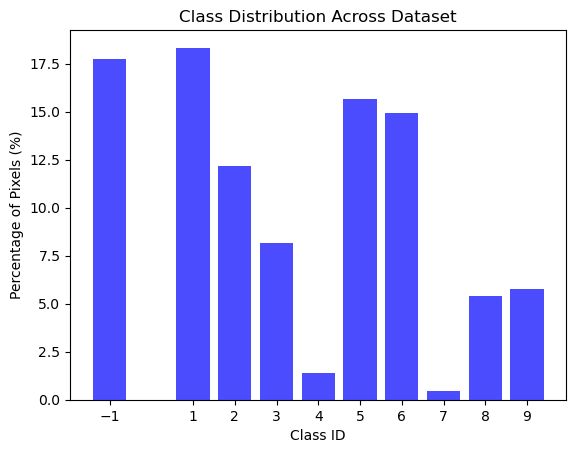

{1: 18.332443340824288,
 2: 12.154766274274932,
 3: 8.181824807072593,
 4: 1.407800309531886,
 5: 15.650532074181648,
 6: 14.925066716311907,
 7: 0.4619624268571913,
 8: 5.392708642511872,
 9: 5.759052085100068,
 -1: 17.733843323333616}

In [16]:
calculate_overall_class_distribution(filtered_labels)


### <a id='toc5_4_3_'></a>[Segregate the labels based on the class](#toc0_)

In [20]:
def calculate_class_distribution(labels_patch):
    """
    Calculate the class distribution for a single patch.
    
    Parameters:
    - labels_patch: numpy array of shape (64, 64), representing the label for the patch.
    
    Returns:
    - class_percentage: dictionary with the class ID as key and percentage of pixels for that class.
    """
    # Flatten the patch for easy counting
    flattened_patch = labels_patch.flatten()
    
    # Calculate class counts
    class_counts = {i: np.sum(flattened_patch == i) for i in range(1,10)}  # Assuming 10 classes
    
    # Calculate total pixels in the patch
    total_pixels = flattened_patch.size
    
    # Calculate percentage of each class
    class_percentage = {cls: float((count / total_pixels) * 100) for cls, count in class_counts.items()}
    
    return class_percentage


In [30]:
def filter_class_based_data_patches(labels, data, threshold=0.75):
    """
    Filters out patches with more than a threshold of "No Data" pixels.
    
    Parameters:
    - labels: numpy array of shape (n, 64, 64)
    - data: numpy array of shape (n, 64, 64, 4)
    - threshold: threshold percentage for class to filter out the patch
    
    Returns:
    - filtered_labels: filtered labels
    - filtered_data: filtered data
    """

    #Creating a dictionary for classifing the pathes into majority classes deceided by the threshold value
    classified_data = {i:[] for i in CROP_IDS}
    classified_labels = {i:[] for i in CROP_IDS}

    #Adding a new patch which has no clear majority
    classified_data[0] = []
    classified_labels[0] = []

    for i in range(labels.shape[0]):
        label_patch = labels[i,...]

        class_distribution = calculate_class_distribution(labels[i,...])
        total_crop_percentage =  np.sum(list(class_distribution.values()))
        classification_margin = threshold * total_crop_percentage

        data_patch = data[i,...]

        #If the patch has a clear majority class, add it to the corresponding list in the dictionary
        if(max(class_distribution.values())>classification_margin):
            major_crop_id = max(class_distribution, key=class_distribution.get)
            #print(major_crop_id, class_distribution)
            classified_data[major_crop_id].append(i)
            classified_labels[major_crop_id].append(label_patch)
        else:
            classified_data[0].append(i)
            classified_labels[0].append(label_patch)
        
    #classified_data[label_patch[0,0]].append(data_patch)
    return classified_data, classified_labels


In [12]:
filtered_labels = np.load((temporal_data_path+'/5_filtered_labels_64X64.npy'))
filtered_data = np.load((temporal_data_path+'/6_filtered_data_64X64.npy'))


In [ ]:
filtered_data.shape


(2948, 144, 64, 64, 4)

In [ ]:
filtered_labels.shape


(2948, 64, 64)

In [31]:
day1_data = filtered_data[:,0, ...]

classified_data, classified_labels = filter_class_based_data_patches(filtered_labels, day1_data, threshold=0.6)

for i in classified_data.keys():
    print(f"Class: {i}, Count: {len(classified_data[i])}")


Class: -1, Count: 0
Class: 1, Count: 449
Class: 2, Count: 297
Class: 3, Count: 164
Class: 4, Count: 22
Class: 5, Count: 382
Class: 6, Count: 351
Class: 7, Count: 5
Class: 8, Count: 91
Class: 9, Count: 118
Class: 0, Count: 1069


# <a id='toc6_'></a>[Data Augumentation](#toc0_)

In [14]:
def get_augmentations():
    return TA.Compose([
        TA.HorizontalFlip(p=0.75),
        TA.VerticalFlip(p=0.75),
        TA.RandomRotate90(p=0.75),  # Only rotate in 90° steps
        TA.RandomCrop(height=56, width=56, p=0.75),
        TA.Resize(height=64, width=64, p=1.0),
    ], additional_targets={'mask': 'mask'})

def augment_patches_temporal(image_patches, label_patches, n_augmentations=5):
    augmented_images = []
    augmented_labels = []
    transform = get_augmentations()

    for img_seq, mask in zip(image_patches, label_patches):
        for _ in range(n_augmentations):
            # Get a replayable transform
            replayed = TA.ReplayCompose(transform.transforms)(image=img_seq[0], mask=mask)
            replay = replayed["replay"]
            aug_mask = replayed["mask"]

            # Apply to all timestamps using same replay
            seq_aug = []
            for frame in img_seq:
                augmented = TA.ReplayCompose.replay(replay, image=frame)
                seq_aug.append(augmented['image'])

            augmented_images.append(np.stack(seq_aug))  # shape: (T, H, W, C)
            augmented_labels.append(aug_mask)

    return np.array(augmented_images), np.array(augmented_labels)


## <a id='toc6_2_'></a>[Augumentation by class](#toc0_)

In [ ]:
no_of_total_images = 500
start_timestamps = 0
end_timestamps = 144
T = end_timestamps - start_timestamps  # total number of timestamps

agumenmted_labels = np.empty((0, 64, 64))
# augumented_data = np.empty((0, T, 64, 64, 4))

for i in tqdm(classified_data.keys(), total=len(classified_data.keys())):
    if i in range(1, 10):
        no_of_original_images = len(classified_data[i])
        required_images = no_of_total_images - no_of_original_images

        if no_of_original_images < no_of_total_images:
            agumentations = int(required_images / no_of_original_images) or 1
            classified_data_sequences = np.empty((0, T, 64, 64, 4))  # Temporal sequences

            # Collect full sequences for each index in the class
            for k in classified_data[i]:
                seq = np.expand_dims(filtered_data[k, start_timestamps:end_timestamps, ...], axis=0)
                classified_data_sequences = np.concatenate((classified_data_sequences, seq), axis=0)

            labels = np.array(classified_labels[i])  # shape: (N, H, W)

            if required_images > no_of_original_images:
                class_augmented_data, class_augmented_labels = augment_patches_temporal(
                    classified_data_sequences, labels, n_augmentations=agumentations
                )
            else:
                data = classified_data_sequences[:required_images, ...]
                label_subset = labels[:required_images, ...]
                class_augmented_data, class_augmented_labels = augment_patches_temporal(
                    data, label_subset, n_augmentations=1
                )

            agumenmted_labels = np.concatenate((agumenmted_labels, class_augmented_labels), axis=0)
            
            filename = '/7_augmented_images_class_'+str(i)+'.npy'
            np.save((temporal_data_path + filename), class_augmented_data)
            # augumented_data = np.concatenate((augumented_data, class_augmented_data), axis=0)

# print(f"Timestamps: {start_timestamps}-{end_timestamps} | Shape: {augumented_data.shape}")

# np.save((temporal_data_path + '/7_augmented_images.npy'), augumented_data)
np.save((temporal_data_path + '/8_agumented_labels'), agumenmted_labels)




100%|██████████| 11/11 [26:35<00:00, 145.07s/it]


# Selecting time range for simplify based on computational resource availability

<!-- Selected date range is for months July-Septembers as it has the lowest average cloud cover compared to the other months -->
V2 - Instead od selecting only a few months data the will be selected in the entire year based on a regular interval with +/- 2 to 3 days difference based on the cloud cover

## Cloud cover and timestamp selection

Detected stack: (144, 2400, 2400, 1) → computed 144 cloud-cover values.


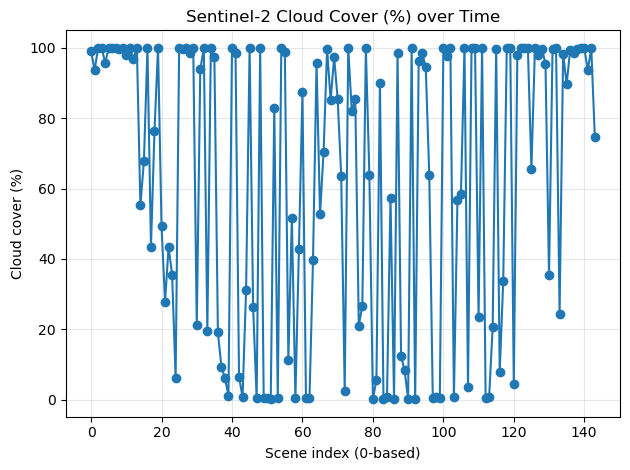

In [6]:
path = dataset + '/SCL.npy'

cloud_data = np.load(path)

# --- CONFIG ---
# 1) Put your file path here (after you upload it):
SCL_PATH = "/path/to/your/denethor_scl.npy"   # or .npz
# 2) Which classes count as "cloud" and which to exclude from denominator:
CLOUD_CLASSES = {7, 8, 9, 10}   # cloud prob low/med/high + thin cirrus
EXCLUDE_FROM_DENOM = {0}        # NoData; add {1} to exclude saturated if you want


# --- COMPUTE CLOUD COVER ---
def pct_cloud_from_scl(scl_2d: np.ndarray) -> float:
    """Return cloud % for a single SCL map."""
    valid_mask = ~np.isin(scl_2d, list(EXCLUDE_FROM_DENOM))
    denom = valid_mask.sum()
    if denom == 0:
        return np.nan
    cloud_mask = np.isin(scl_2d, list(CLOUD_CLASSES)) & valid_mask
    return 100.0 * cloud_mask.sum() / denom

cloud_series = None

T = cloud_data.shape[0]
cloud_series = np.empty(T, dtype=float)
for t in range(T):
    cloud_series[t] = pct_cloud_from_scl(cloud_data[t])
print(f"Detected stack: {cloud_data.shape} → computed {T} cloud-cover values.")


# --- PLOT ---
plt.figure()
plt.plot(np.arange(cloud_series.size), cloud_series, marker="o")
plt.title("Sentinel-2 Cloud Cover (%) over Time")
plt.xlabel("Scene index (0-based)")
plt.ylabel("Cloud cover (%)")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


In [7]:
# This code checks around fixed indexes of 3 day step and does not change its offset if the cloud cover is before and after the index date

selected_indices_fixed = []

for i in range(0, len(cloud_series), 3):
    if i == 0:
        cur_list = [cloud_series[i], cloud_series[i+1]]
        res = np.where(cur_list == np.min(cur_list))[0]

        if res == 0:
            selected_indices_fixed.append(i)
        else:
            selected_indices_fixed.append(i+1)
    else:
        cur_list = [cloud_series[i]-1, cloud_series[i], cloud_series[i+1]]
        res = np.where(cur_list == np.min(cur_list))[0]

        if res == 0:
            selected_indices_fixed.append(i-1)
        elif res == 1:
            selected_indices_fixed.append(i)
        else:
            selected_indices_fixed.append(i+1)

print(selected_indices_fixed)
print(len(selected_indices_fixed))




[1, 4, 5, 10, 11, 14, 17, 20, 23, 28, 29, 32, 37, 38, 43, 46, 49, 50, 55, 58, 61, 62, 65, 70, 71, 76, 79, 80, 83, 88, 89, 92, 97, 98, 103, 104, 107, 112, 113, 116, 119, 122, 127, 130, 133, 134, 137, 140]
48


In [9]:
selected_indices = []

i=0
while i<len(cloud_series):
    if i == 0:
        cur_list = [cloud_series[i], cloud_series[i+1]]
        res = np.where(cur_list == np.min(cur_list))[0]

        if res == 0:
            selected_indices.append(i)
        else:
            selected_indices.append(i+1)
            i = i+1
    elif i+1 < (len(cloud_series)-1):
        cur_list = [cloud_series[i]-1, cloud_series[i], cloud_series[i+1]]        
        res = np.where(cur_list == np.min(cur_list))[0]

        if res == 0:
            selected_indices.append(i-1)
            i = i-1
        elif res == 1:
            selected_indices.append(i)
        else:
            selected_indices.append(i+1)
            i = i+1
    else:
        cur_list = [cloud_series[i]-1, cloud_series[i]]        
        res = np.where(cur_list == np.min(cur_list))[0]

        if res == 0:
            selected_indices.append(i-1)
            i = i-1
        elif res == 1:
            selected_indices.append(i)

    i+=3
    

print(selected_indices)
print(len(selected_indices))


[1, 3, 5, 7, 9, 11, 13, 17, 21, 23, 25, 27, 29, 33, 37, 41, 43, 47, 49, 53, 55, 57, 61, 65, 67, 71, 73, 75, 79, 83, 85, 89, 91, 95, 97, 101, 103, 107, 109, 111, 113, 115, 117, 119, 121, 125, 129, 133, 135, 137, 141]
51


In [10]:
select_dates_cloud_cover_fixed = cloud_series[selected_indices_fixed]
print(select_dates_cloud_cover_fixed)

################################################################
select_dates_cloud_cover_dynamic = cloud_series[selected_indices]
print(select_dates_cloud_cover_fixed)
print('-'*50)
################################################################
sum, mean, var, sum_dev, min_val, max_val = (
    np.sum(select_dates_cloud_cover_fixed),
    np.mean(select_dates_cloud_cover_fixed),
    np.var(select_dates_cloud_cover_fixed),
    np.sum(np.abs(select_dates_cloud_cover_fixed - np.mean(select_dates_cloud_cover_fixed))),  # sum of absolute deviations from mean
    np.min(select_dates_cloud_cover_fixed),
    np.max(select_dates_cloud_cover_fixed)
)

print(f'sum: {sum}, mean: {mean}, var: {var}, sum_dev: {sum_dev}, min_val: {min_val}, max_val {max_val}')

################################################################
sum, mean, var, sum_dev, min_val, max_val = (
    np.sum(select_dates_cloud_cover_dynamic),
    np.mean(select_dates_cloud_cover_dynamic),
    np.var(select_dates_cloud_cover_dynamic),
    np.sum(np.abs(select_dates_cloud_cover_dynamic - np.mean(select_dates_cloud_cover_dynamic))),  # sum of absolute deviations from mean
    np.min(select_dates_cloud_cover_dynamic),
    np.max(select_dates_cloud_cover_dynamic)
)

print(f'sum: {sum}, mean: {mean}, var: {var}, sum_dev: {sum_dev}, min_val: {min_val}, max_val {max_val}')


[ 93.7425      95.780625    99.93631944  98.01638889  99.99986111
  55.37        43.41730903  49.21791667  35.51736111  98.65791667
  99.99993056 100.           9.27611111   6.18930556   0.7925
  26.19055556   0.42229167   0.38604167  98.88944444   0.46625
   0.389375     0.35645833  52.63486111  85.46159722  63.70645833
  21.03520833  63.83993056   0.14972222   0.19472222  12.33701389
   8.326875     0.16305556   0.48402946   0.75541719   0.66756944
  56.63659722   3.62548863   0.56604167   0.79180556   7.82791667
  99.98847222 100.          98.07486111  35.34444444  24.33898847
  98.36618056  98.44618056 100.        ]
[ 93.7425      95.780625    99.93631944  98.01638889  99.99986111
  55.37        43.41730903  49.21791667  35.51736111  98.65791667
  99.99993056 100.           9.27611111   6.18930556   0.7925
  26.19055556   0.42229167   0.38604167  98.88944444   0.46625
   0.389375     0.35645833  52.63486111  85.46159722  63.70645833
  21.03520833  63.83993056   0.14972222   0.19472

## Saving DOY for TGAN 

In [11]:
selected_dates = np.array(readable_dates)[selected_indices_fixed]
dt_series = pd.to_datetime(selected_dates)

# Get DOY (day of year)
doy = np.array(dt_series.dayofyear)/365
np.save((temporal_data_path+'/13_selected_dates_DOY_normalised.npy'), doy)


## Original data

### Without minority patches

In [38]:
majority_original_data = np.empty((0, 48, 64, 64, 4))
majority_original_labels = np.empty((0, 64, 64))
start_timestamp = 71
end_timestamp = 108
T = end_timestamp-start_timestamp

for i in range(1,10):
    if len(classified_data[i])>0:
        labels = np.array(classified_labels[i])

        classified_data_sequences = np.empty((0, 144, 64, 64, 4))  # Temporal sequences

        # Collect full sequences for each index in the class
        for k in classified_data[i]:
            seq = np.expand_dims(filtered_data[k, ...], axis=0)
            classified_data_sequences = np.concatenate((classified_data_sequences, seq), axis=0)

        majority_original_data = np.concatenate((majority_original_data, classified_data_sequences[:, selected_indices_fixed, ...]), axis=0)
        majority_original_labels = np.concatenate((majority_original_labels, labels), axis=0)

        print(majority_original_data.shape)
        print(majority_original_labels.shape)
    

(449, 48, 64, 64, 4)
(449, 64, 64)
(746, 48, 64, 64, 4)
(746, 64, 64)
(910, 48, 64, 64, 4)
(910, 64, 64)
(932, 48, 64, 64, 4)
(932, 64, 64)
(1314, 48, 64, 64, 4)
(1314, 64, 64)
(1665, 48, 64, 64, 4)
(1665, 64, 64)
(1670, 48, 64, 64, 4)
(1670, 64, 64)
(1761, 48, 64, 64, 4)
(1761, 64, 64)
(1879, 48, 64, 64, 4)
(1879, 64, 64)


In [39]:
# print('Before reshape: ', majority_original_data.shape)
# majority_original_data = np.swapaxes(majority_original_data, 0, 1)
# print('After reshape: ', majority_original_data.shape)

majority_original_data = majority_original_data.astype(np.float32)
majority_original_labels = majority_original_labels.astype(int)


In [40]:
majority_original_labels.shape


(1879, 64, 64)

In [41]:
np.save((temporal_data_path+'/14_selected_time_range_filtered_data_3_a_month_majority60.npy'), majority_original_data)
np.save((temporal_data_path+'/15_selected_time_range_filtered_labels_3_a_month_majority60.npy'), majority_original_labels)


In [42]:
type(majority_original_data[0,0,0,0,0])


numpy.float32

### With miority patches

In [ ]:
# print('Before reshape: ', filtered_data.shape)
# filtered_data = np.swapaxes(filtered_data, 0, 1)
# print('After reshape: ', filtered_data.shape)


Before reshape:  (2948, 144, 64, 64, 4)
After reshape:  (144, 2948, 64, 64, 4)


In [ ]:
filtered_data.shape


(2948, 144, 64, 64, 4)

In [47]:
selected_time_range = filtered_data[: , selected_indices_fixed, ...]
print(selected_time_range.shape)

np.save((temporal_data_path+'/16_selected_time_range_filtered_data_3_a_month_with_minority_patches.npy'), selected_time_range)
# Labels for these are '5_filtered_labels_64X64.npy'


(2948, 48, 64, 64, 4)


In [49]:
selected_time_range = np.load(temporal_data_path+'/16_selected_time_range_filtered_data_3_a_month_with_minority_patches.npy')
selected_time_range.shape


(2948, 48, 64, 64, 4)

In [48]:
type(selected_time_range[0,0,0,0,0])


numpy.float32

## Augumented data

In [11]:
T = 48
selected_agumeneted_time_range_data = np.empty((0, T, 64, 64, 4))

for i in range(1, 10):
    filename = '/7_augmented_images_class_'+str(i)+'.npy'
    agumeneted_time_range_data = np.load(temporal_data_path+filename)

    print(agumeneted_time_range_data[:, selected_indices_fixed, ...].shape)

    selected_agumeneted_time_range_data = np.concatenate((selected_agumeneted_time_range_data, agumeneted_time_range_data[:, selected_indices_fixed, ...]), axis=0) 

print(selected_agumeneted_time_range_data.shape)


(51, 48, 64, 64, 4)
(203, 48, 64, 64, 4)
(328, 48, 64, 64, 4)
(462, 48, 64, 64, 4)
(118, 48, 64, 64, 4)
(149, 48, 64, 64, 4)
(495, 48, 64, 64, 4)
(364, 48, 64, 64, 4)
(354, 48, 64, 64, 4)
(2524, 48, 64, 64, 4)


In [12]:
# print('Before reshape: ', selected_agumeneted_time_range_data.shape)
# selected_agumeneted_time_range_data = np.swapaxes(selected_agumeneted_time_range_data, 0,1)
# print('After reshape: ', selected_agumeneted_time_range_data.shape)

np.save((temporal_data_path+'/17_selected_time_range_augumented_data_3_a_month.npy'), selected_agumeneted_time_range_data)
# Labels for these are 8_agumented_labels.npy


## View class distribution post augmentation

In [13]:
final_gan_labels = np.empty((0, 64, 64))

majority_original_labels = np.load(temporal_data_path+'/15_selected_time_range_filtered_labels_3_a_month_majority60.npy')
agumenmted_labels = np.load(temporal_data_path+'/8_agumented_labels.npy')

final_gan_labels = np.concatenate((final_gan_labels, majority_original_labels), axis=0)
final_gan_labels = np.concatenate((final_gan_labels, agumenmted_labels), axis=0)


In [14]:
majority_original_labels.shape


(1879, 64, 64)

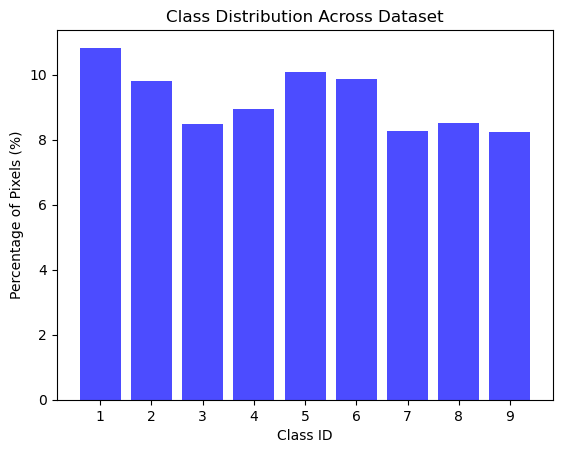

{1: 10.829075612508516,
 2: 9.805171012661821,
 3: 8.495616891182149,
 4: 8.932985145071543,
 5: 10.091607905831252,
 6: 9.869302978792868,
 7: 8.26386905057631,
 8: 8.528071015145922,
 9: 8.222315794983533}

In [17]:
calculate_overall_class_distribution(final_gan_labels, False)


In [ ]:
# final_gan_data = np.load(('../Dataset/s2-utm-33N-18E-242N-2018/DS3/2_normalised_rgb_nir_train_data_2018-07-31.npy'))
final_gan_data = np.load(('../Dataset/s2-utm-33N-18E-242N-2018/DS3/2_normalised_rgb_nir_train_data_2018-07-31.npy'))
# final_gan_labels = np.load((temporal_data_path+'/19_final_TGAN_labels.npy'))


In [25]:
final_gan_data.shape


(2400, 2400, 4)

In [26]:
#img = final_gan_data[1,1,...].astype(np.float32)
img = np.array([final_gan_data])
img = (img+1)/2

img.shape


(1, 2400, 2400, 4)

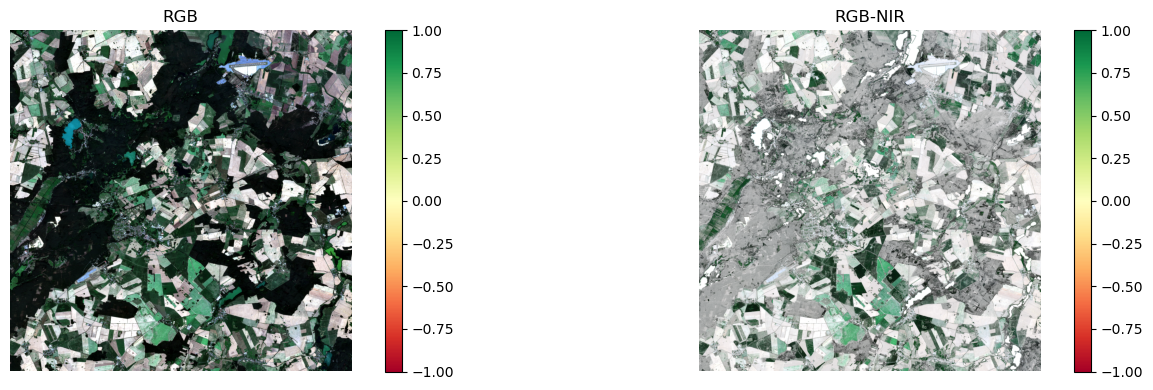

In [27]:
display_images(img)
